In [11]:
# Cellule 1 : Importations des packages requis
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium

# Métriques et algorithmes scikit-learn imposés par le sujet
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Configuration des graphiques matplotlib
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') # Style propre pour le rapport

In [12]:
# Cellule 2 : Chargement du jeu de données issu de la partie Big Data
fichier_csv = "export_IA.csv"

if not os.path.exists(fichier_csv):
    raise FileNotFoundError(f"Le fichier '{fichier_csv}' est introuvable. "
                            f"Veuillez le placer dans le même dossier que ce Notebook.")

df = pd.read_csv(fichier_csv)
print(f"✅ Fichier chargé avec succès ! Nombre total de lignes : {len(df)}")

# Aperçu des colonnes pour s'assurer de la présence des coordonnées géographiques
print("\nColonnes disponibles dans le fichier :")
print(df.columns.tolist())

✅ Fichier chargé avec succès ! Nombre total de lignes : 4783

Colonnes disponibles dans le fichier :
['contact_operateur', 'nom_enseigne', 'id_station_itinerance', 'nom_station', 'implantation_station', 'adresse_station', 'coordonneesXY', 'nbre_pdc', 'id_pdc_itinerance', 'puissance_nominale', 'prise_type_ef', 'prise_type_2', 'prise_type_combo_ccs', 'prise_type_chademo', 'prise_type_autre', 'paiement_acte', 'tarification', 'condition_acces', 'reservation', 'horaires', 'accessibilite_pmr', 'restriction_gabarit', 'station_deux_roues', 'date_maj', 'last_modified', 'datagouv_dataset_id', 'datagouv_resource_id', 'datagouv_organization_or_owner', 'created_at', 'consolidated_longitude', 'consolidated_latitude', 'consolidated_code_postal', 'consolidated_commune', 'consolidated_is_lon_lat_correct', 'consolidated_is_code_insee_verified', 'consolidated_is_code_insee_modified']


In [13]:
# Cellule 3 : Sélection et filtrage des variables géographiques
# Définition des noms de colonnes (ajustez si vos colonnes s'appellent 'lat'/'lon' ou 'latitude'/'longitude')
col_latitude = 'consolidated_latitude'
col_longitude = 'consolidated_longitude'

# Suppression des valeurs manquantes uniquement sur les coordonnées
X = df[[col_latitude, col_longitude]].dropna()
print(f"Nombre de bornes valides prêtes pour le clustering : {len(X)}")

# Étape indispensable : Standardisation (Centrage-Réduction)
# K-Means calcule des distances euclidiennes ; les variables doivent avoir la même échelle.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nAperçu des données standardisées (5 premières lignes) :")
print(X_scaled[:5])

Nombre de bornes valides prêtes pour le clustering : 4783

Aperçu des données standardisées (5 premières lignes) :
[[-1.52301852 -0.74090223]
 [-1.63773471 -0.40650504]
 [ 0.80335149  0.20526147]
 [ 0.08765524 -0.73355584]
 [ 0.08767562 -0.73355357]]


In [14]:
# Cellule 4 : Boucle d'expérimentation pour faire varier le nombre de clusters (K de 3 à 10)
resultats_metriques = []
inerties = []
k_range = range(3, 11)

print("Début de l'apprentissage non supervisé et calcul des indices de performance...")

for k in k_range:
    # Initialisation et entraînement du K-Means pour chaque K
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # Enregistrement de l'inertie (pour la méthode du coude)
    inerties.append(kmeans.inertia_)
    
    # Calcul des 3 métriques explicitement demandées par le sujet
    score_silhouette = silhouette_score(X_scaled, labels)
    index_calinski = calinski_harabasz_score(X_scaled, labels)
    index_davies = davies_bouldin_score(X_scaled, labels)
    
    # Stockage des indicateurs
    resultats_metriques.append({
        'K (Nb Clusters)': k,
        'Silhouette Coefficient': score_silhouette,  # Idéalement proche de 1
        'Calinski-Harabasz Index': index_calinski,    # Idéalement le plus élevé possible
        'Davies-Bouldin Index': index_davies          # Idéalement proche de 0
    })
    print(f" -> Évaluation terminée pour K = {k}")

# Conversion des résultats en DataFrame pour affichage sous forme de tableau
df_bilan = pd.DataFrame(resultats_metriques)
print("\n=== TABLEAU DE SYNTHÈSE DES MÈTRIQUES (À inclure dans votre rapport) ===")
df_bilan

Début de l'apprentissage non supervisé et calcul des indices de performance...
 -> Évaluation terminée pour K = 3
 -> Évaluation terminée pour K = 4
 -> Évaluation terminée pour K = 5
 -> Évaluation terminée pour K = 6
 -> Évaluation terminée pour K = 7
 -> Évaluation terminée pour K = 8
 -> Évaluation terminée pour K = 9
 -> Évaluation terminée pour K = 10

=== TABLEAU DE SYNTHÈSE DES MÈTRIQUES (À inclure dans votre rapport) ===


,K (Nb Clusters),Silhouette Coefficient,Calinski-Harabasz Index,Davies-Bouldin Index
0,3,0.458986,4442.821359,0.768998
1,4,0.465045,4677.595348,0.725173
2,5,0.479927,5249.307571,0.717391
3,6,0.496120,5431.466997,0.727850
4,7,0.460790,5446.648395,0.760498
5,8,0.463416,5449.469352,0.744052
6,9,0.469333,5587.479400,0.707573
7,10,0.464764,5839.894172,0.756042


💾 Graphique 'metriques_clustering_position.png' enregistré avec succès dans votre répertoire.


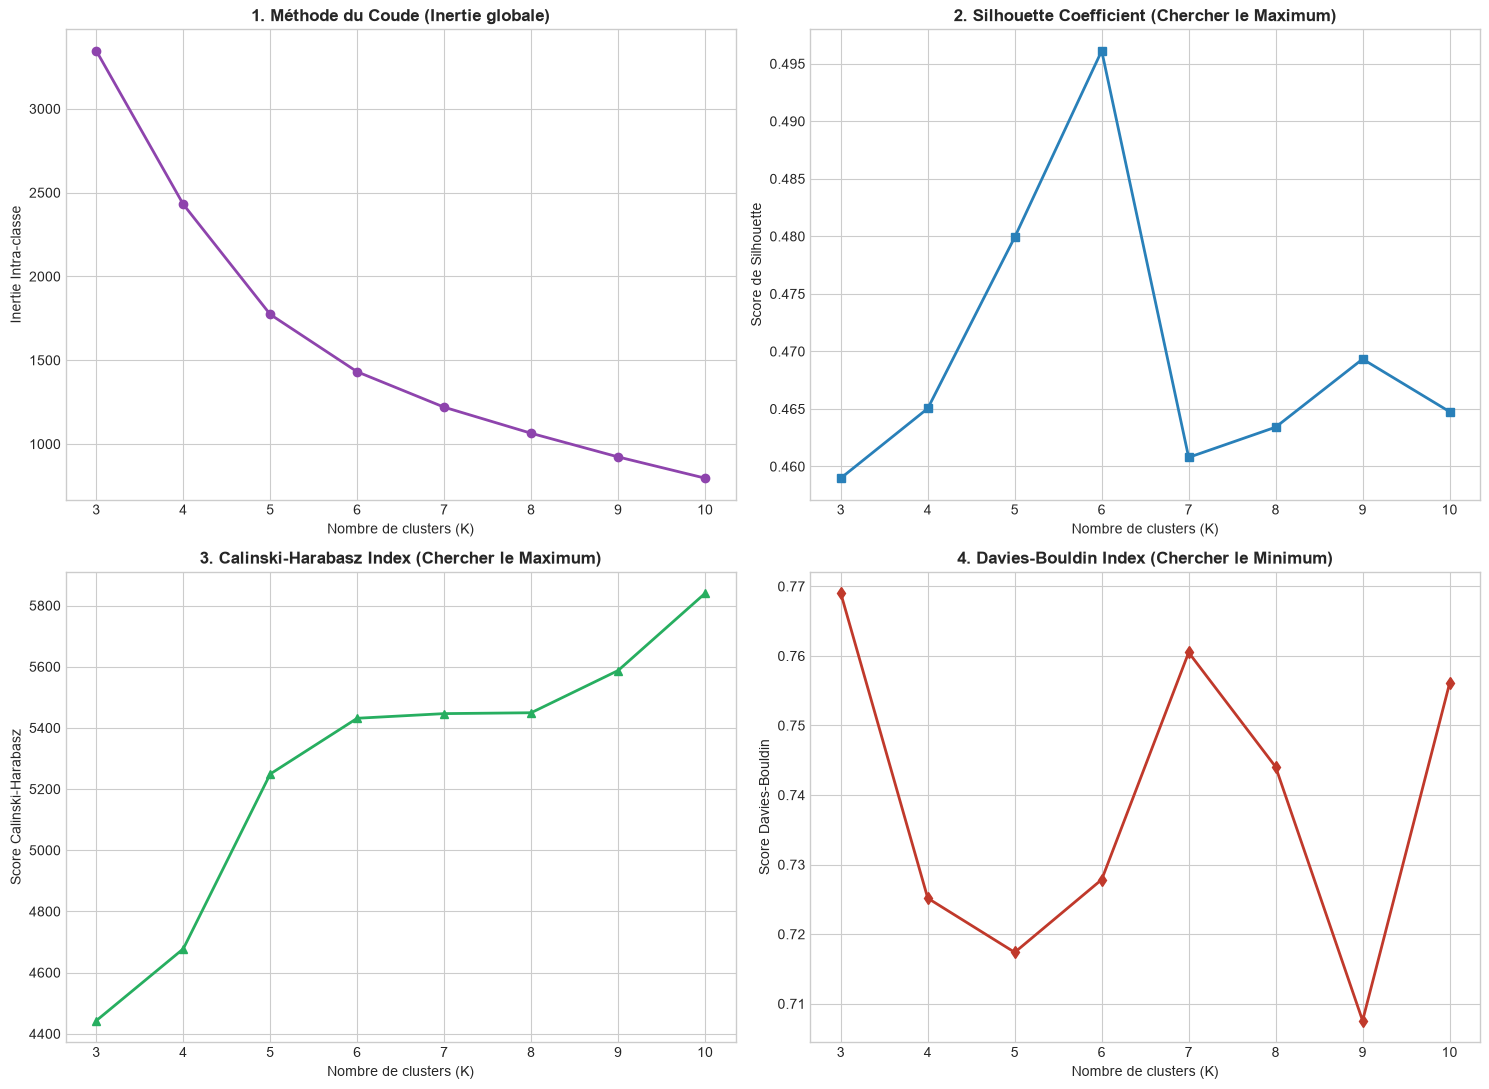

In [15]:
# Cellule 5 : Tracé des 4 courbes d'analyse pour la recherche du K optimal
fig, axs = plt.subplots(2, 2, figsize=(15, 11))

# 1. Courbe de l'Inertie (Méthode du Coude)
axs[0, 0].plot(k_range, inerties, marker='o', linewidth=2, color='#8e44ad')
axs[0, 0].set_title("1. Méthode du Coude (Inertie globale)", fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel("Nombre de clusters (K)")
axs[0, 0].set_ylabel("Inertie Intra-classe")

# 2. Courbe du Coefficient de Silhouette
axs[0, 1].plot(k_range, df_bilan['Silhouette Coefficient'], marker='s', linewidth=2, color='#2980b9')
axs[0, 1].set_title("2. Silhouette Coefficient (Chercher le Maximum)", fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel("Nombre de clusters (K)")
axs[0, 1].set_ylabel("Score de Silhouette")

# 3. Courbe de l'Index Calinski-Harabasz
axs[1, 0].plot(k_range, df_bilan['Calinski-Harabasz Index'], marker='^', linewidth=2, color='#27ae60')
axs[1, 0].set_title("3. Calinski-Harabasz Index (Chercher le Maximum)", fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel("Nombre de clusters (K)")
axs[1, 0].set_ylabel("Score Calinski-Harabasz")

# 4. Courbe de l'Index Davies-Bouldin
axs[1, 1].plot(k_range, df_bilan['Davies-Bouldin Index'], marker='d', linewidth=2, color='#c0392b')
axs[1, 1].set_title("4. Davies-Bouldin Index (Chercher le Minimum)", fontsize=12, fontweight='bold')
axs[1, 1].set_xlabel("Nombre de clusters (K)")
axs[1, 1].set_ylabel("Score Davies-Bouldin")

plt.tight_layout()

# Sauvegarde automatique de l'image pour l'insérer facilement dans votre rapport Word/PDF
plt.savefig("metriques_clustering_position.png", dpi=300)
print("💾 Graphique 'metriques_clustering_position.png' enregistré avec succès dans votre répertoire.")
plt.show()

In [16]:
# Cellule 6 : Fixation du K optimal et sérialisation des objets
# NOTE POUR L'ÉTUDIANT : Analysez le tableau et les graphes ci-dessus pour adapter cette valeur.
# En France, pour les bornes de recharge, K=5 ou K=6 offre généralement le meilleur compromis mathématique/métier.
K_optimal = 5 

print(f"Application définitive du modèle K-Means avec K = {K_optimal}...")
modele_final = KMeans(n_clusters=K_optimal, random_state=42, n_init=10)

# Calcul et assignation des numéros de clusters au jeu de données original
X['cluster'] = modele_final.fit_predict(X_scaled)

# SAUVEGARDE STRICTE DES FICHIERS POUR LE SCRIPT DE PRODUCTION (predict_cluster.py)
# Cette étape répond à la consigne d'interdiction de réentraîner le modèle en production.
with open("scaler_clustering.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("model_clustering.pkl", "wb") as f:
    pickle.dump(modele_final, f)

print("📦 Le 'Scaler' et le 'Modèle K-Means' ont été figés et sauvegardés sous format .pkl.")

Application définitive du modèle K-Means avec K = 5...
📦 Le 'Scaler' et le 'Modèle K-Means' ont été figés et sauvegardés sous format .pkl.


In [17]:
# Cellule 7 : Génération de la carte HTML demandée par le cahier des charges
print("Création de la carte de visualisation sectorisée...")

# Calcul du point central moyen pour initialiser la vue de la carte
centre_carte = [X[col_latitude].mean(), X[col_longitude].mean()]
carte_interactive = folium.Map(location=centre_carte, zoom_start=6, tiles="OpenStreetMap")

# Palette fixe de couleurs distinctes pour représenter graphiquement chaque groupe
couleurs_clusters = ['red', 'blue', 'green', 'purple', 'orange', 'cadetblue', 'darkred', 'darkblue', 'darkgreen', 'gray']

# Échantillonnage de sécurité : si votre fichier contient des dizaines de milliers de bornes,
# afficher chaque point figerait votre navigateur Web. On prend un échantillon aléatoire représentatif de 1500 points.
taille_echantillon = min(1500, len(X))
df_visualisation = X.sample(n=taille_echantillon, random_state=42)

# Ajout des bornes sous forme de marqueurs colorés
for index, rangee in df_visualisation.iterrows():
    id_groupe = int(rangee['cluster'])
    
    folium.CircleMarker(
        location=[rangee[col_latitude], rangee[col_longitude]],
        radius=3.5,
        color=couleurs_clusters[id_groupe % len(couleurs_clusters)],
        fill=True,
        fill_color=couleurs_clusters[id_groupe % len(couleurs_clusters)],
        fill_opacity=0.7,
        popup=f"Borne IRVE - Cluster Affecté : {id_groupe}"
    ).add_to(carte_interactive)

# Enregistrement de la carte au format web HTML autonome
carte_interactive.save("carte_clusters_bornes.html")
print("🌐 Fichier 'carte_clusters_bornes.html' généré. Vous pouvez double-cliquer dessus pour l'ouvrir dans un navigateur.")

Création de la carte de visualisation sectorisée...
🌐 Fichier 'carte_clusters_bornes.html' généré. Vous pouvez double-cliquer dessus pour l'ouvrir dans un navigateur.
